<a href="https://colab.research.google.com/github/sigvehaug/MLwPython/blob/master/3_ML_SL_TreesForests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning with Trees and Forests



PD Dr. Sigve Haug, 2026. https://github.com/sigvehaug/MLwPython

Based on notebooks by Mykhailo Vladymyrov & Aris Marcolongo. https://github.com/neworldemancer/DSF5

This work is licensed under <a href="https://creativecommons.org/share-your-work/public-domain/cc0/">CC0</a>.



## Learning outcomes

- Know pros and cons of trees and forests
- Know how tree models work
- Know how forests work
- Know that feature importance is
- Can train, use and assess trees and forests
- Can assess feature importance

## Table of Content


- Decision Trees
- Random Forests
- Boosted Decision Trees (XGBoost)
- Exercise: Random forest for FMNIST
- Feature Importance for Interpretable Machine Learning
- Exercise: Random Forest for AMES with Feature Importance

## Decision Trees




With linear models one fits straight lines, or hyperplanes in higher dimensions, in the feature space. If the dataset boundaries don't follow straight lines, this is not optimal. Decision trees are models that overcome this limitation. They are

- fast to train
- easily interpretable
- non-linear and
- require small amount of data

They easily overfit. The remedy for that are forests. There are tree models for classification and regression. They can be trained (fitted) by examples (labeled/annotaded data) and thus belongs to the supervised learning paradigm.




The following example shows that each tree creates a partition of the feature space $X$ into subregions $R_i$, $i=1,...,N_R$, this partitioning being described by a tree structure.


Predictions will be made with the following procedure. Given a new test point:
1. Assign $x$ to the region it belongs, e.g. $R_k$
2. For classification, make a majority vote using the training points belonging to $R_k$. For regression, evaluate the mean of the target over all training points belonging to $R_k$.

Let's see how the trees generate a partition of the domain into distinct regions.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn import tree

training score : 0.667 (depth=1)


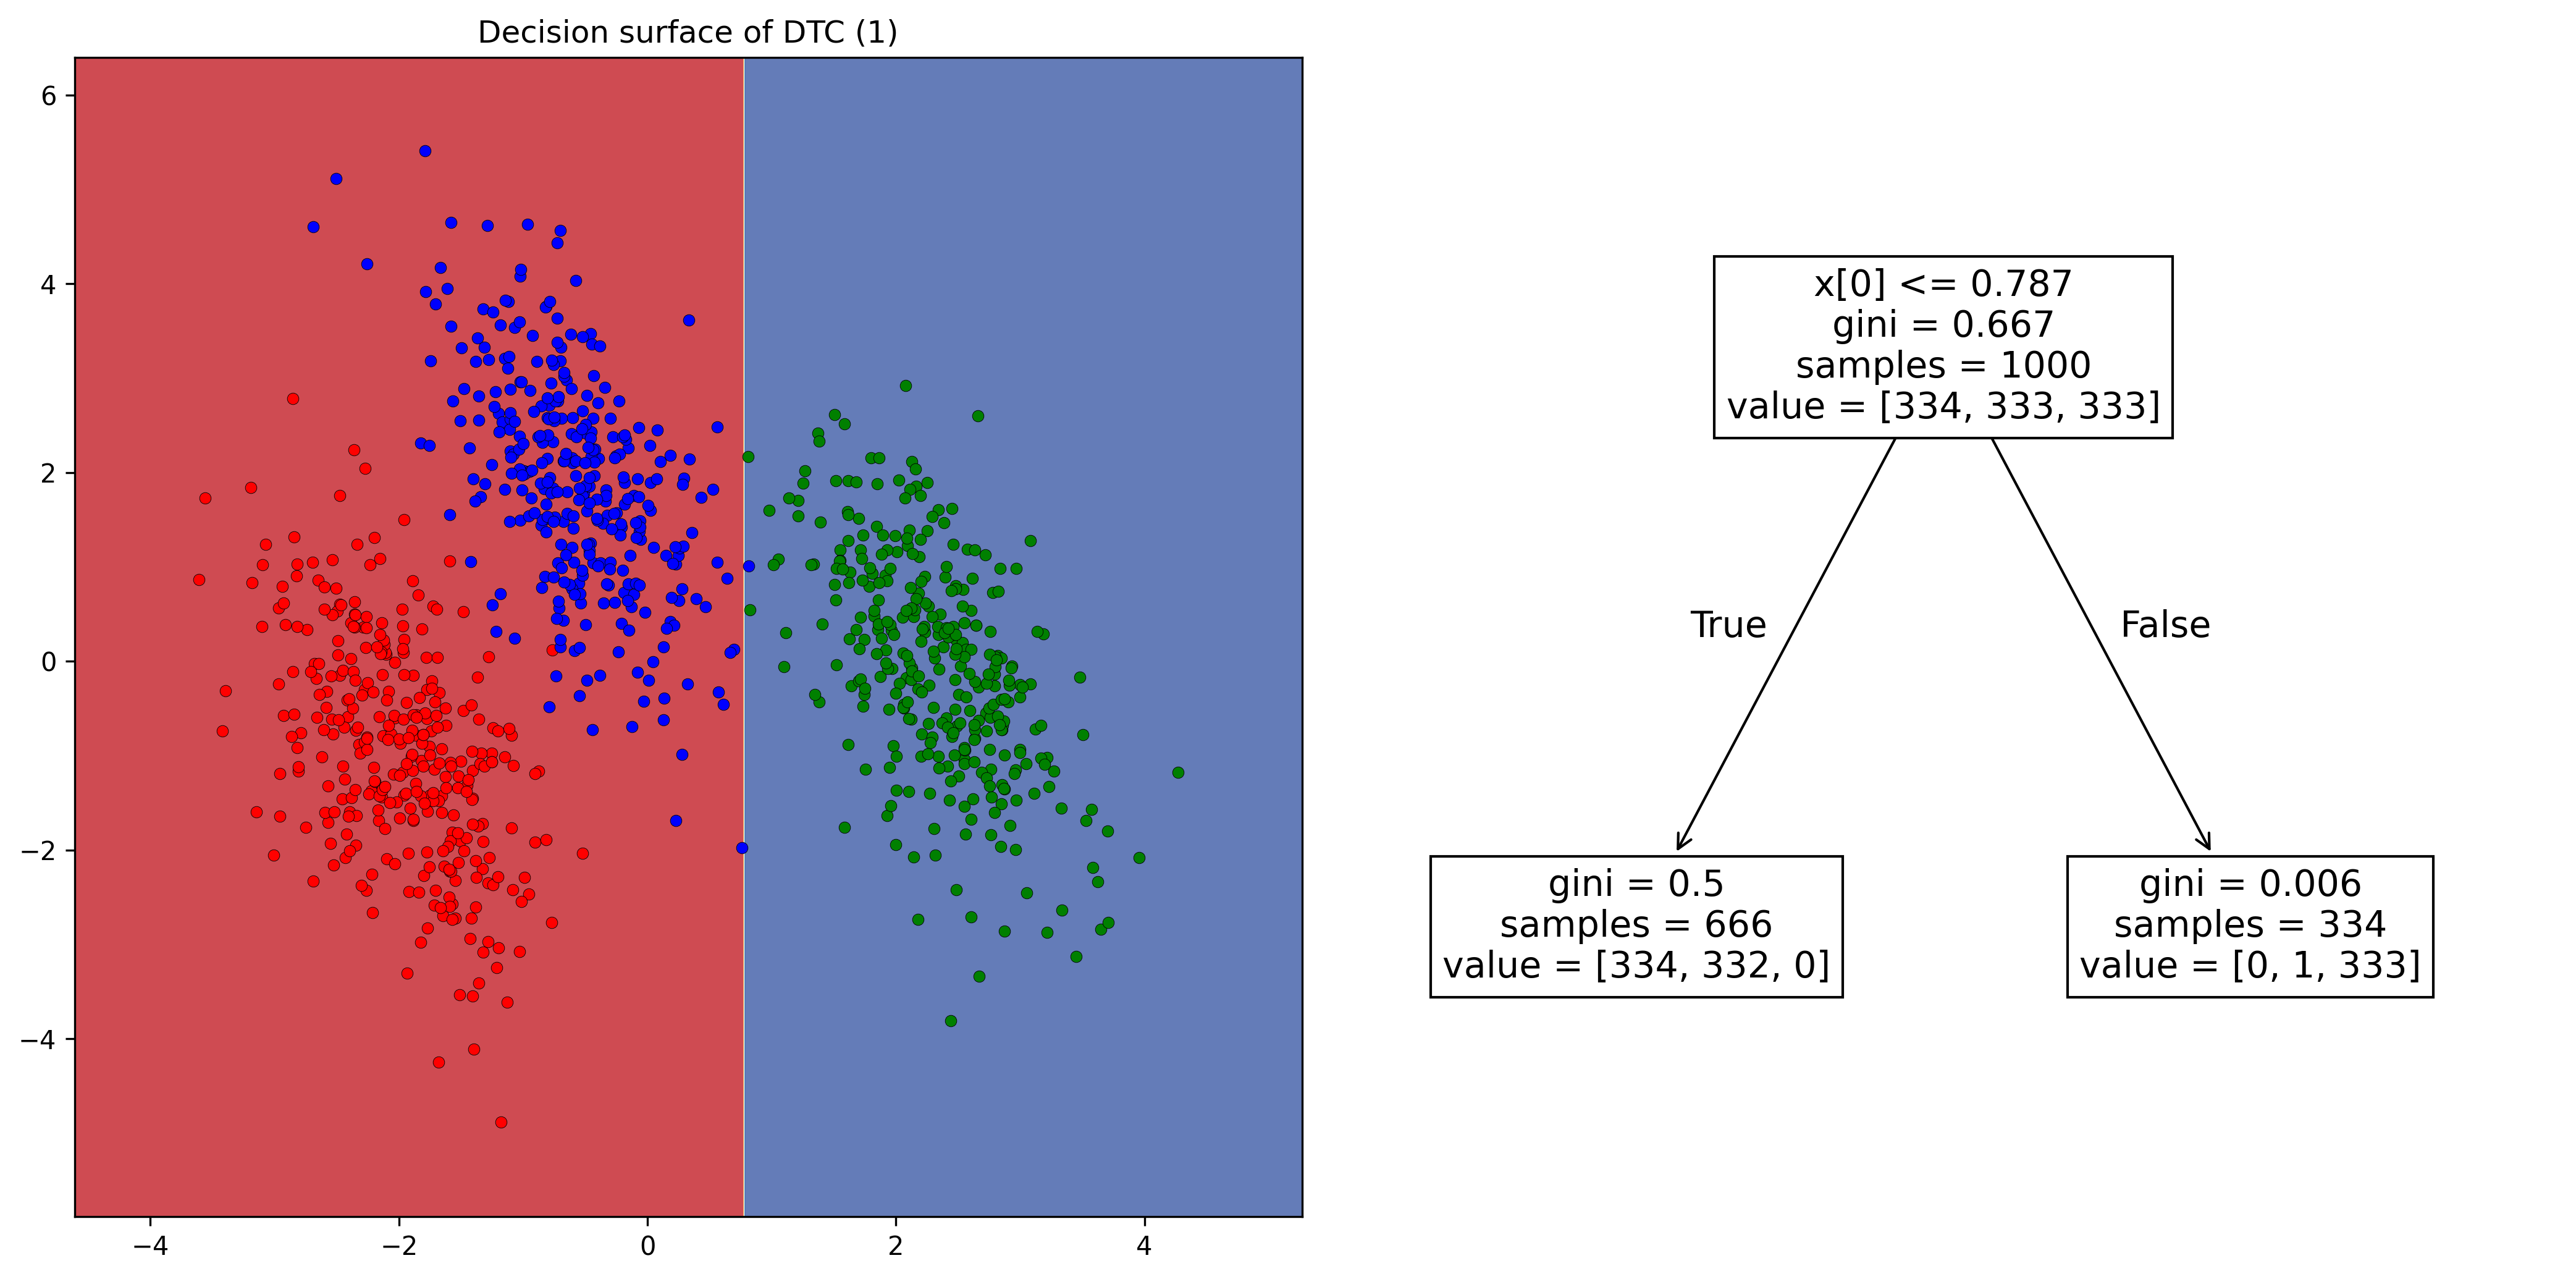

training score : 0.942 (depth=2)


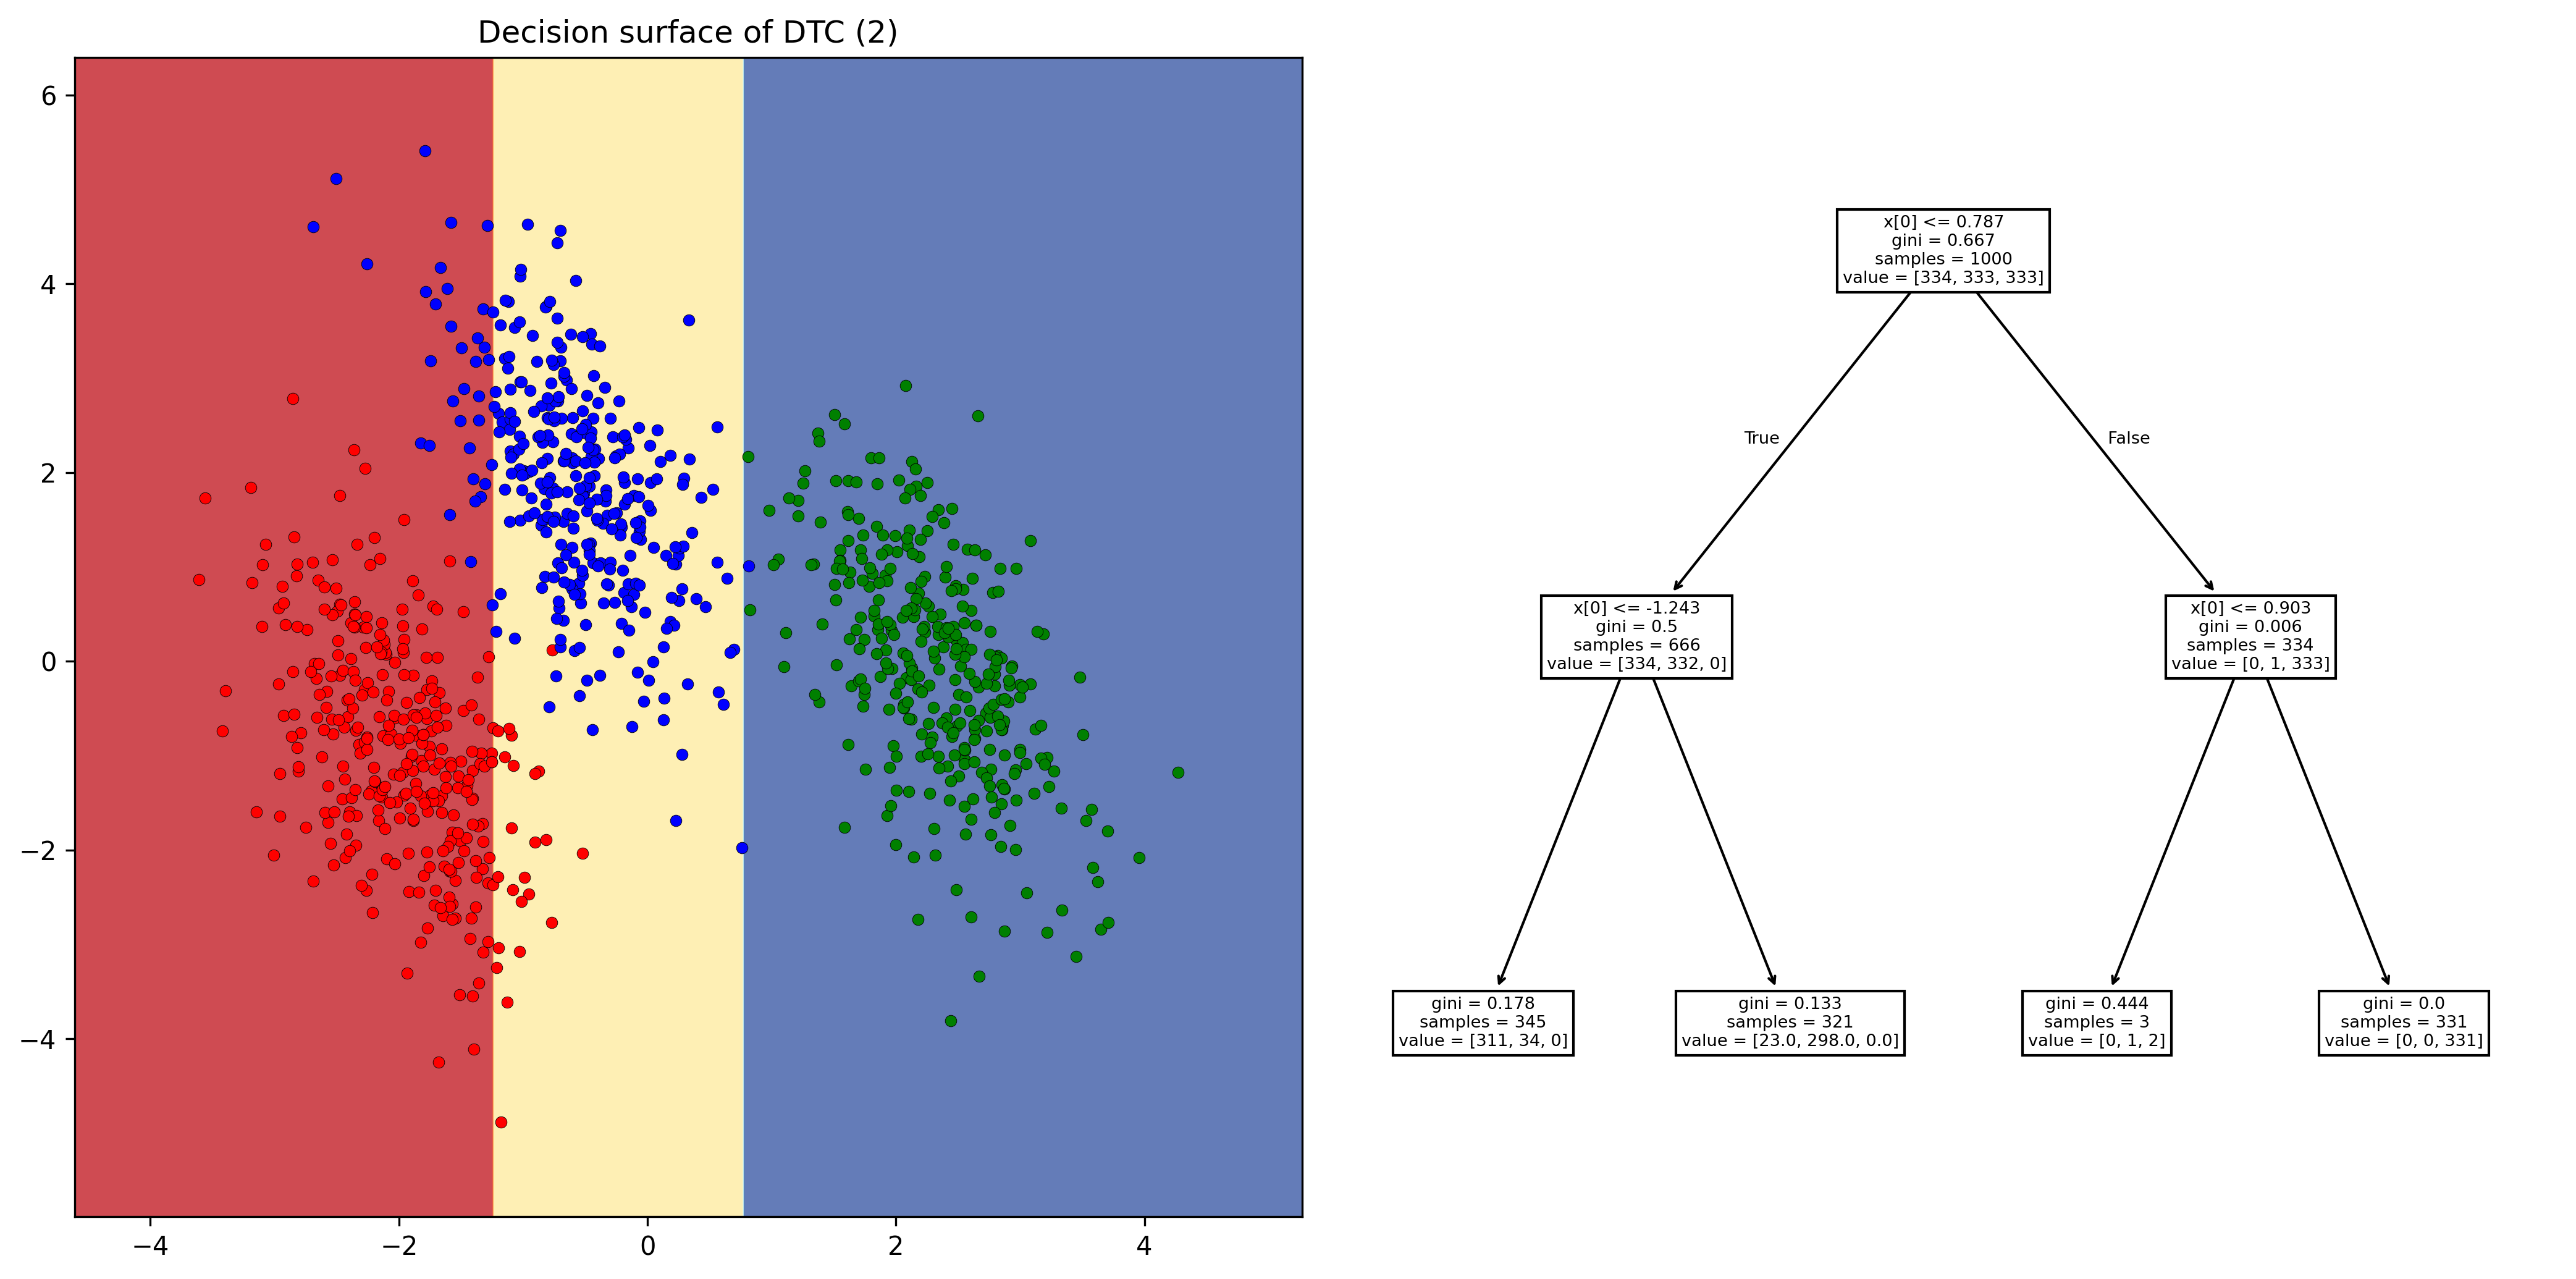

training score : 0.986 (depth=3)


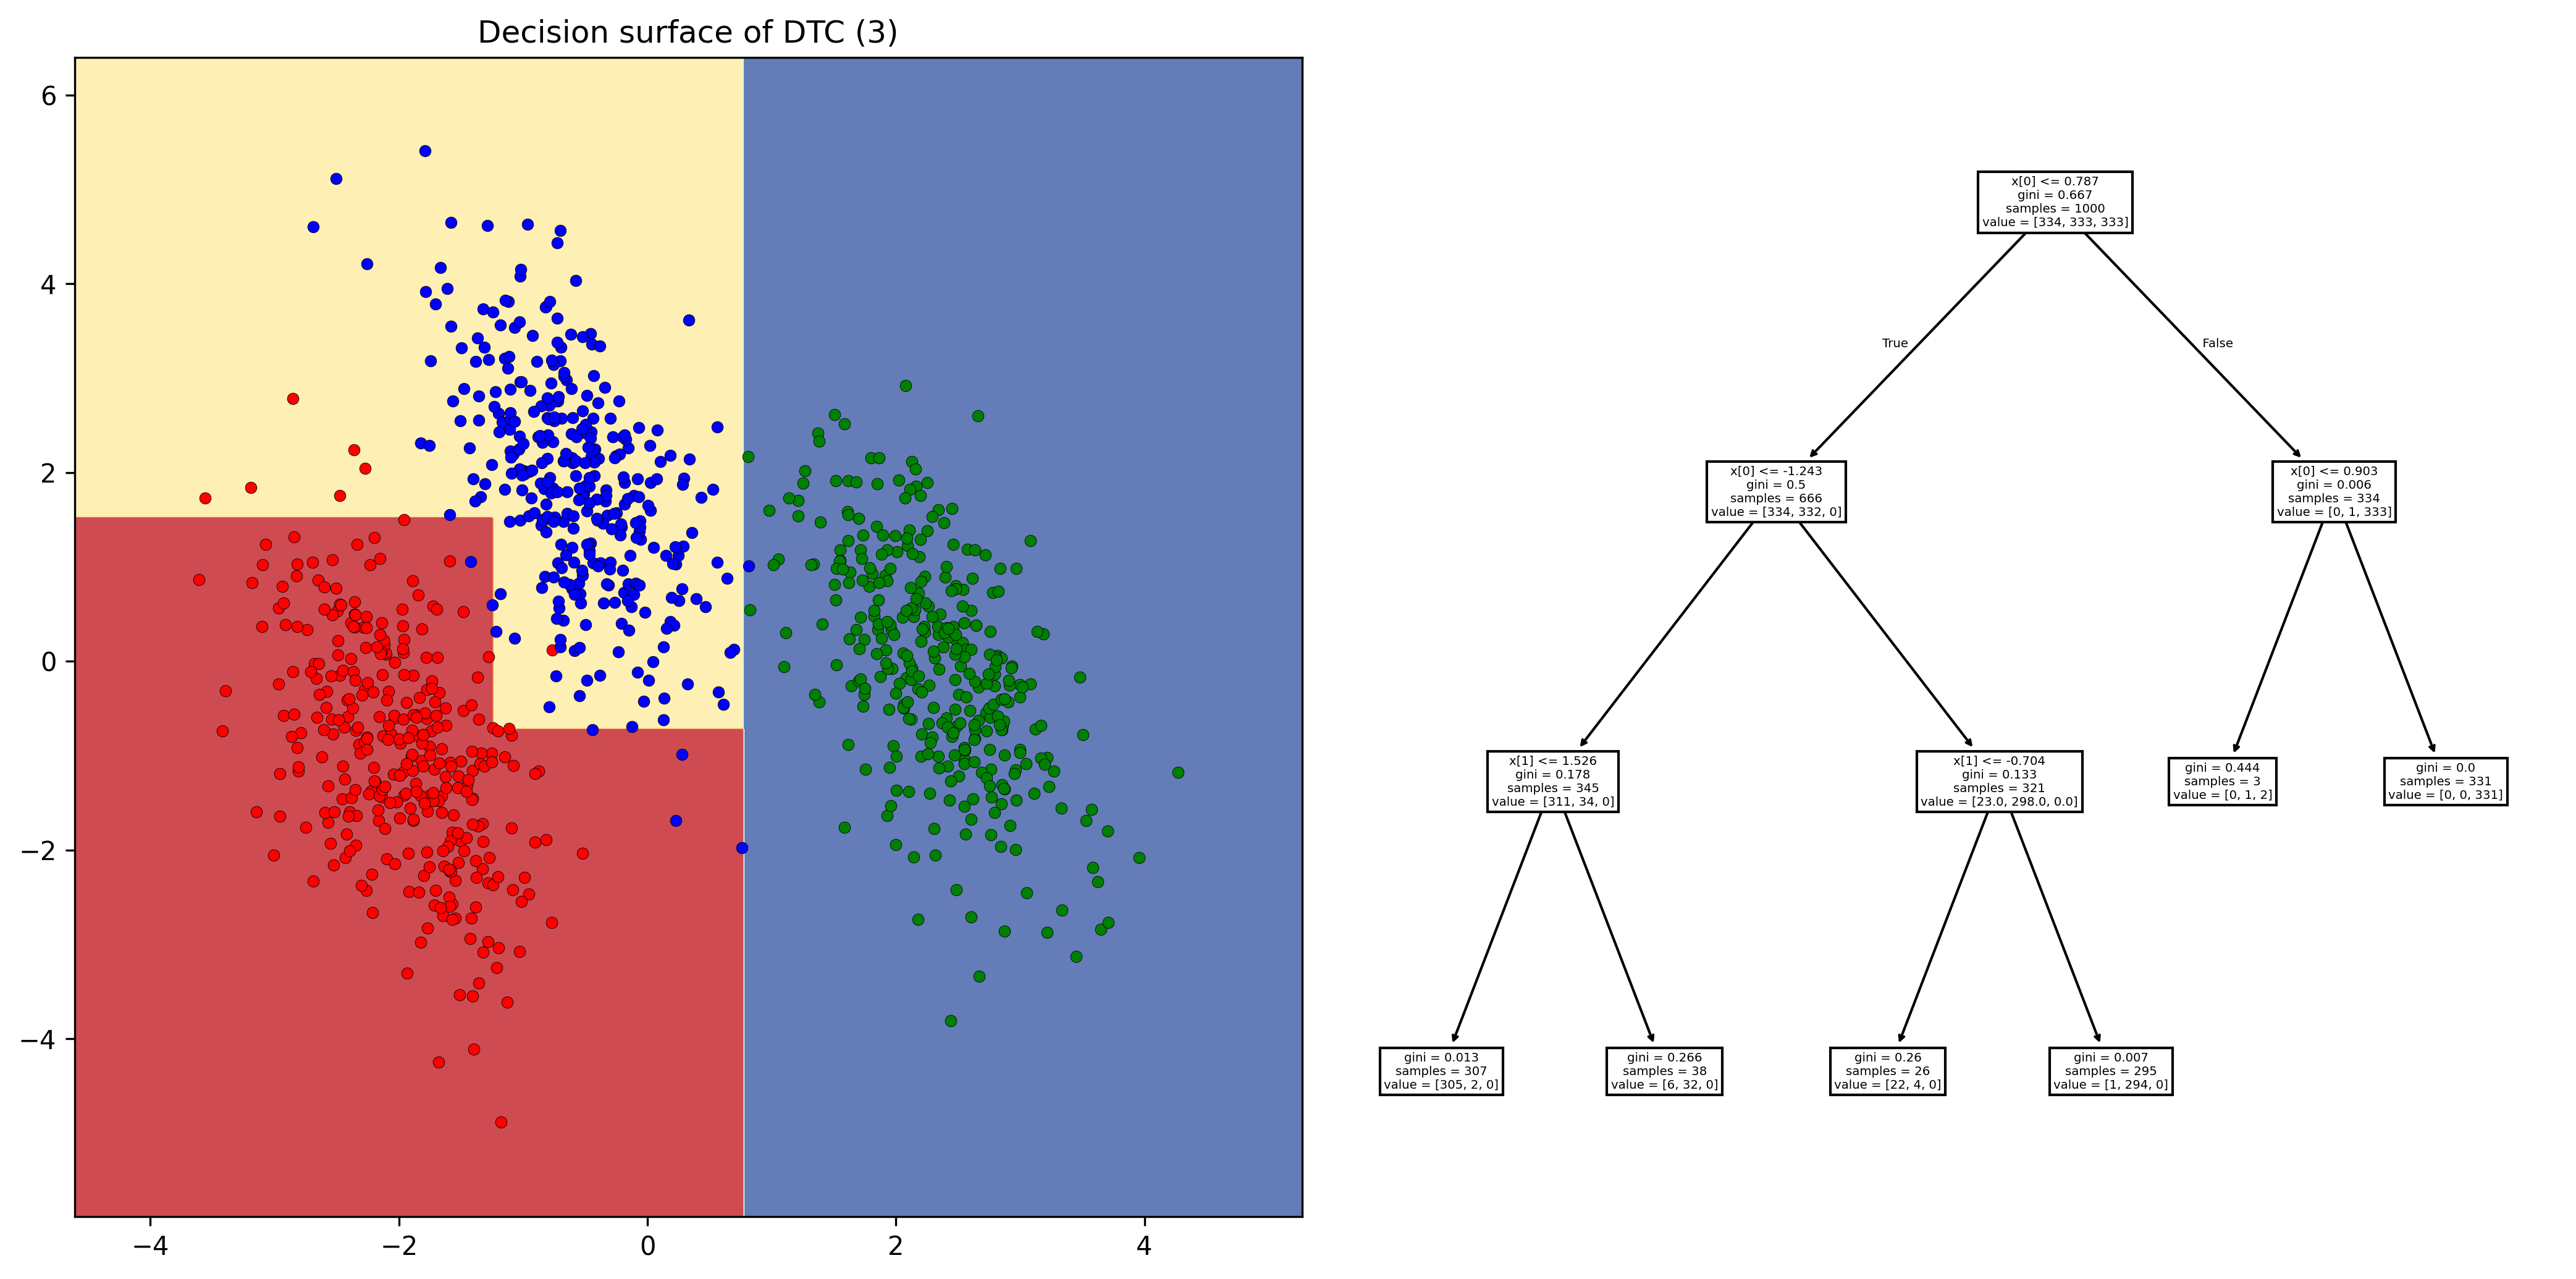

training score : 0.994 (depth=4)


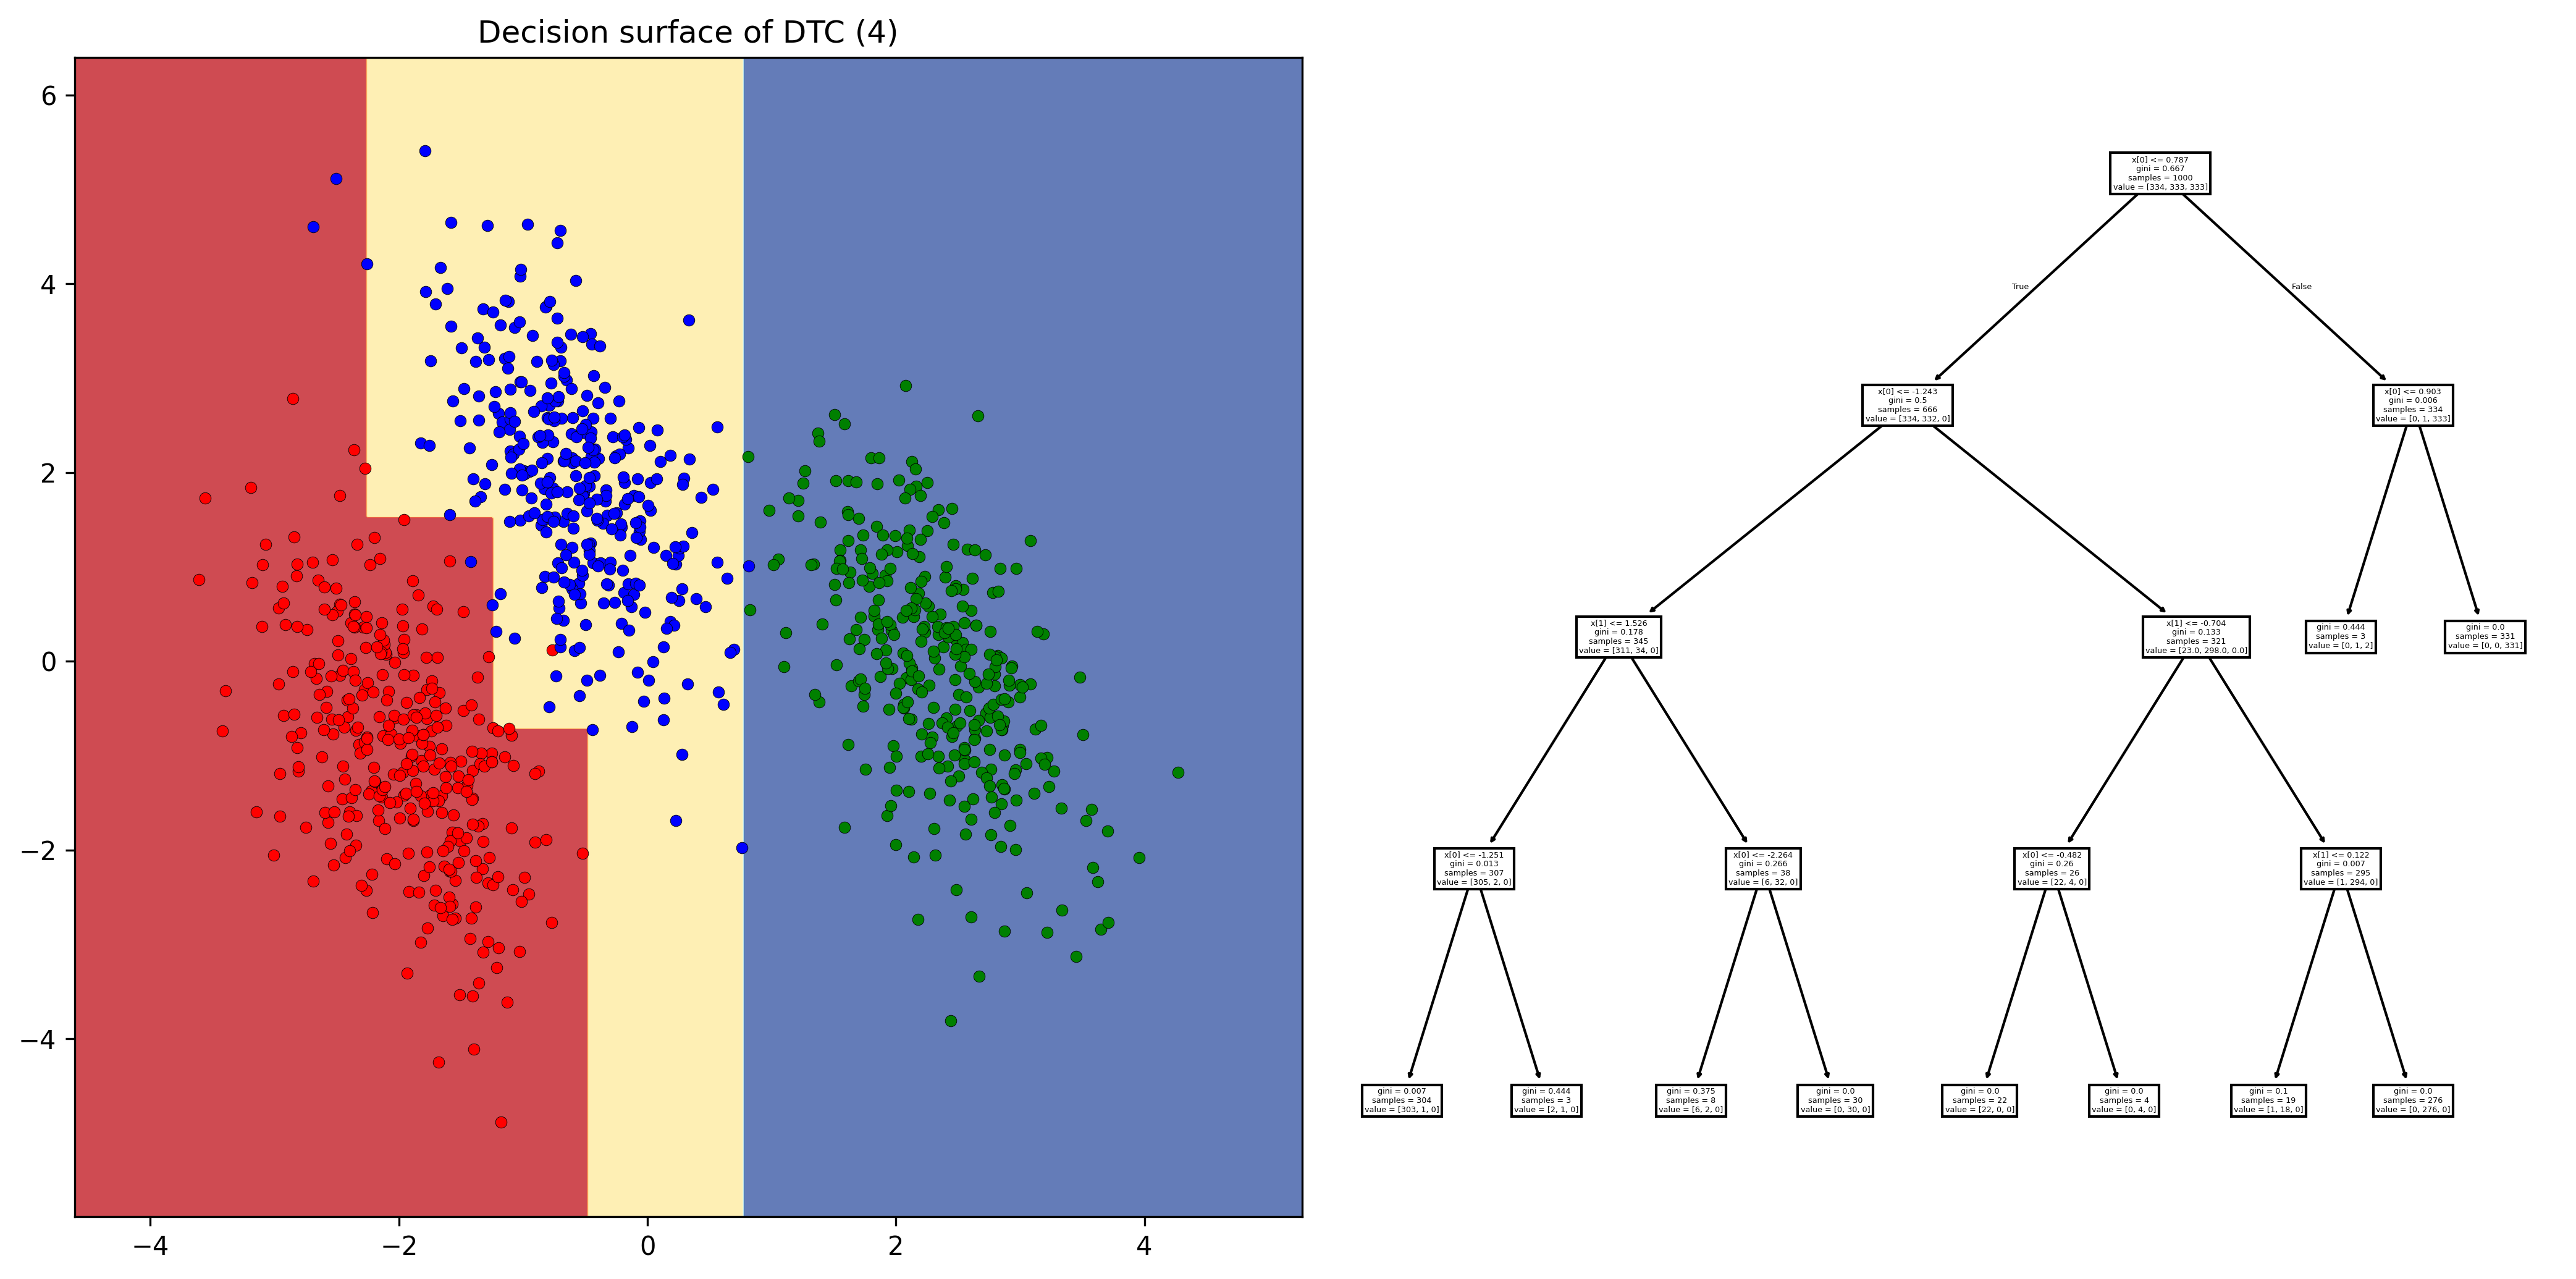

In [7]:
# make 3-class dataset for classification

def plot_prediction_2d(x_min, x_max, y_min, y_max, classifier, ax):
    # Create a meshgrid to plot the decision boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict class for each point in the meshgrid
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision surface
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)


centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=40)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)
dtcs = []
for depth in (1, 2, 3, 4):
    # do fit
    dtc = tree.DecisionTreeClassifier(max_depth=depth, criterion='gini', min_samples_leaf=3)  # 'entropy'
    dtcs.append(dtc)
    dtc.fit(X, y)

    # print the training scores
    print("training score : %.3f (depth=%d)" % (dtc.score(X, y), depth))

    # get range for visualization
    x_0 = X[:, 0]
    x_1 = X[:, 1]
    x_min = x_0.min() - 1
    x_max = x_0.max() + 1
    y_min = x_1.min() - 1
    y_max = x_1.max() + 1

    fig, ax = plt.subplots(1, 2,  figsize=(14,7), dpi=300)
    plot_prediction_2d(x_min, x_max, y_min, y_max, classifier=dtc, ax=ax[0])

    ax[0].set_title("Decision surface of DTC (%d)" % depth)

    # Plot also the training points
    colors = "rbg"
    for i, color in zip(dtc.classes_, colors):
        idx = np.where(y == i)
        ax[0].scatter(x_0[idx], x_1[idx], c=color,
                    edgecolor='black', s=20, linewidth=0.2)

    with plt.style.context('classic'):
      tree.plot_tree(dtc, ax=ax[1]);

    plt.tight_layout()
    plt.show()

### How is the tree constructed from a labelled training set?

### Classification
Given a sample $S$ of $N$ points in feature space ($x_i$, $i=1...N$), each assigned to one of $C$ classes ($c_i \in \{1,..,C\}$), we compute class proportions:
$$p_c = \frac{N_c}{N}$$
where $N_c$ is the number of points in class $c$.

**Impurity measures:**
- **Gini index:**
  $$G(S) = 1 - \sum_c p_c^2$$
- **Entropy:**
  $$E(S) = -\sum_c p_c \log(p_c)$$

These quantify how mixed the classes are in a node.

**Splitting:**
- At each step, choose a feature and cutoff $a$.
- Points with $x_{i,k} < a$ go left; $x_{i,k} \ge a$ go right.
- Define $S_{<}$, $S_{>}$ and their sizes $N_{<}$, $N_{>}$.
- **Information gain:**
  $$ IG = E(S) - \frac{N_{<}}{N} E(S_{<}) - \frac{N_{>}}{N} E(S_{>}) $$
- (Same formula for Gini index.)
- The split with highest information gain is chosen, favoring relevant features at the top and helping reduce overfitting by pruning.

---
### Regression
Similar setup, but targets are real values $y_i \in \mathbb{R}$.

**Splitting criterion:**
- Use sample variance:
  $$V(S) = \frac{1}{N} \sum_i (y_i - \bar{y})^2$$
- After splitting, compute means $y_{<}$ and $y_{>}$ for left/right nodes.
- **Reduction in variance:**
  $$ \frac{N_{<}}{N} V(S_{<}) + \frac{N_{>}}{N} V(S_{>}) = \frac{1}{N}\left(\sum_{i \in S_{<}} (y_i-y_{<})^2 + \sum_{i \in S_{>}} (y_i-y_{>})^2\right) $$
- The best split maximizes reduction in variance.

---
These are known as the **CART** (Classification and Regression Trees) splitting criteria.

## Random Forests

The `sklearn.ensemble` provides several ensemble algorithms. RandomForest is an averaging algorithm based on randomized decision trees. This means a diverse set of classifiers is created by introducing randomness in the classifier construction.

The prediction of the ensemble is given as the averaged prediction of the individual classifiers (regression) or by majority voting (classification). E.g. for regression:

$$ RF(x) = \frac{1}{N_\text{trees}}\sum_{i=1}^{N_\text{trees}} Tree_i(x)$$

Individual decision trees typically exhibit high variance and tend to overfit.
In random forests:
* each tree in the ensemble is built from a sample drawn with replacement (i.e., a bootstrap sample) from the training set.
* when splitting each node during the construction of a tree, the best split is found from a random subset of features, according to `max_features` parameter.

The injected randomness in forests yield decision trees with somewhat decoupled prediction errors. By taking an average of those predictions, some errors can cancel out. Random forests achieve a reduced variance by combining diverse trees, sometimes at the cost of a slight increase in bias. In practice the variance reduction is often significant, hence yielding an overall better model.


training score : 0.960 (n_est=1)


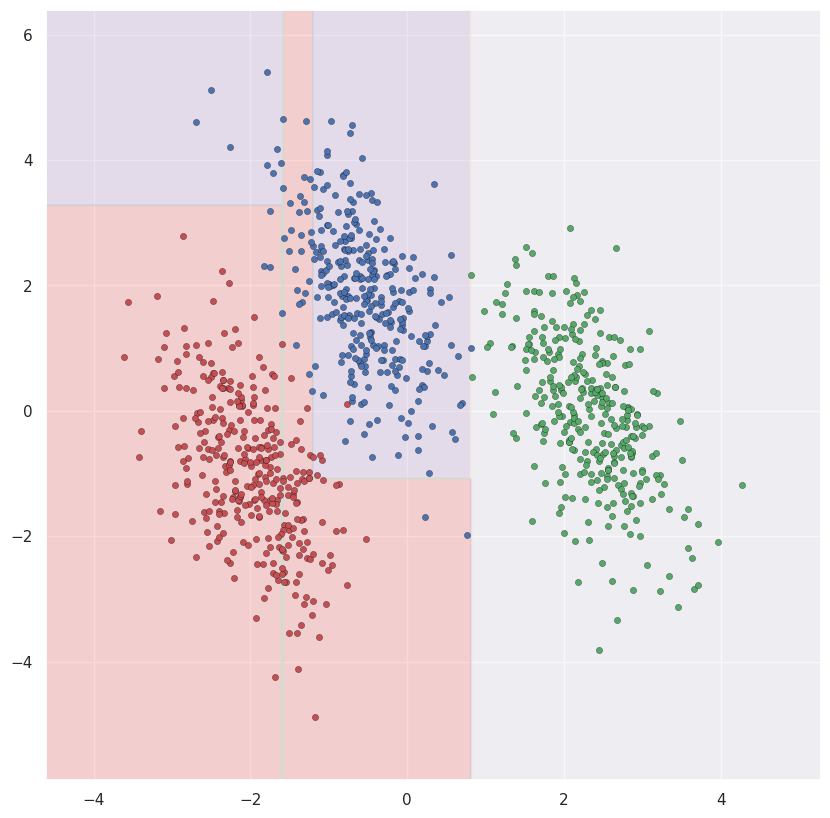

training score : 0.976 (n_est=4)


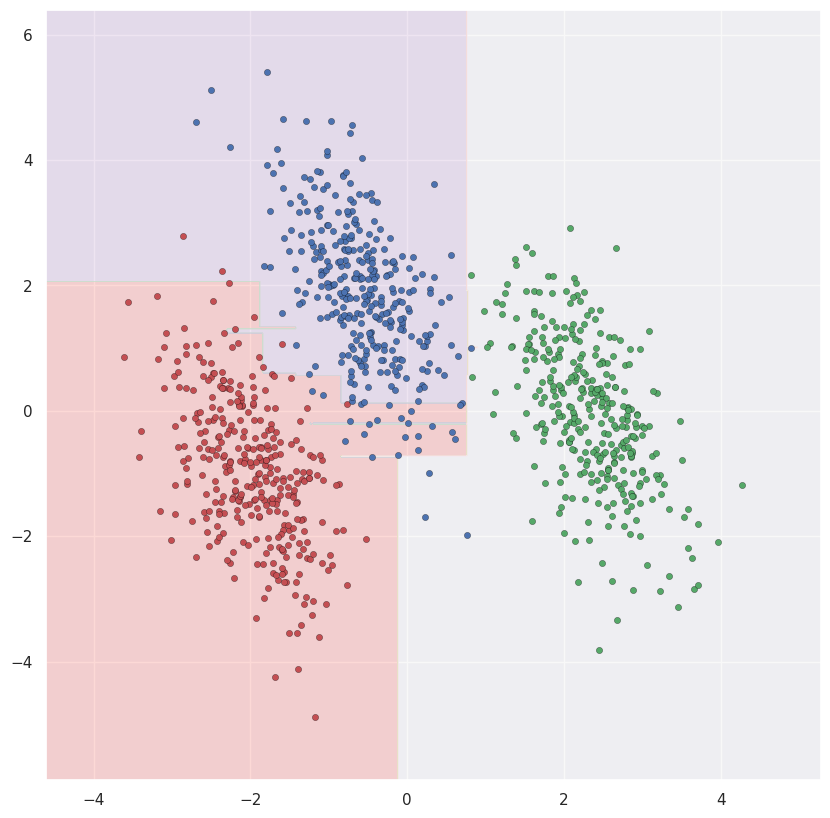

training score : 0.997 (n_est=50)


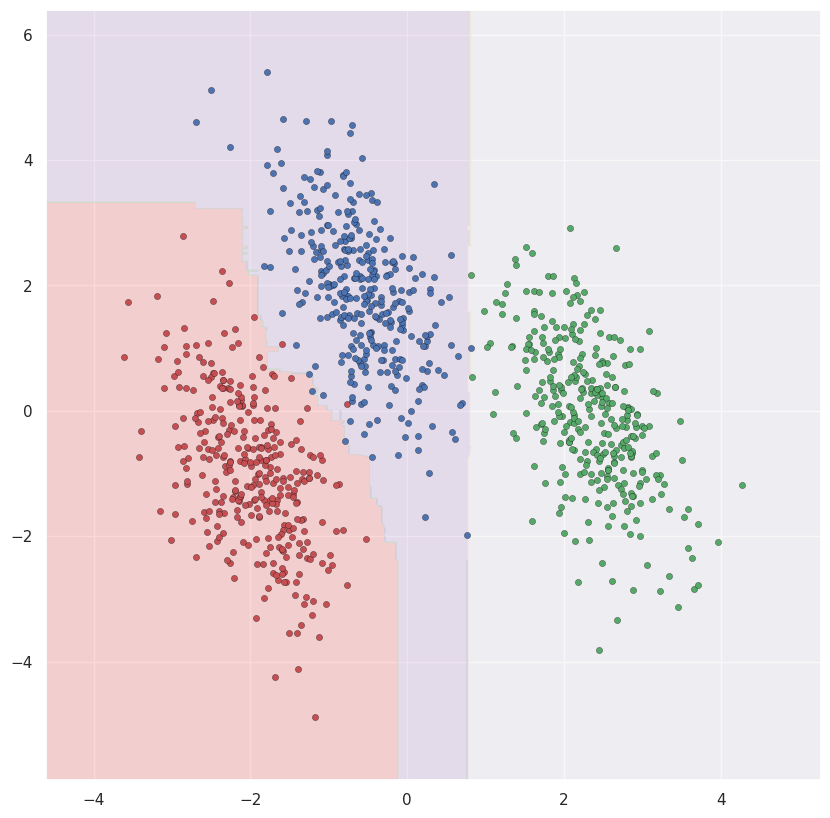

In [ ]:
# make 3-class dataset for classification
centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=40)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

for n_est in (1, 4, 50):
    # do fit
    rfc = ensemble.RandomForestClassifier(max_depth=4, n_estimators=n_est,)
    rfc.fit(X, y)

    # print the training scores
    print("training score : %.3f (n_est=%d)" % (rfc.score(X, y), n_est))

    # get range for visualization
    x_0 = X[:, 0]
    x_1 = X[:, 1]
    x_min = x_0.min() - 1
    x_max = x_0.max() + 1
    y_min = x_1.min() - 1
    y_max = x_1.max() + 1

    plt.figure(figsize=(10,10))
    plot_prediction_2d(x_min, x_max, y_min, y_max, classifier=rfc)

    # Plot also the training points
    colors = 'rbg'
    for i, color in enumerate(colors):
        idx = np.where(y == i)
        plt.scatter(x_0[idx], x_1[idx], c=color,
                    edgecolor='black', s=20, linewidth=0.2)


    plt.show()

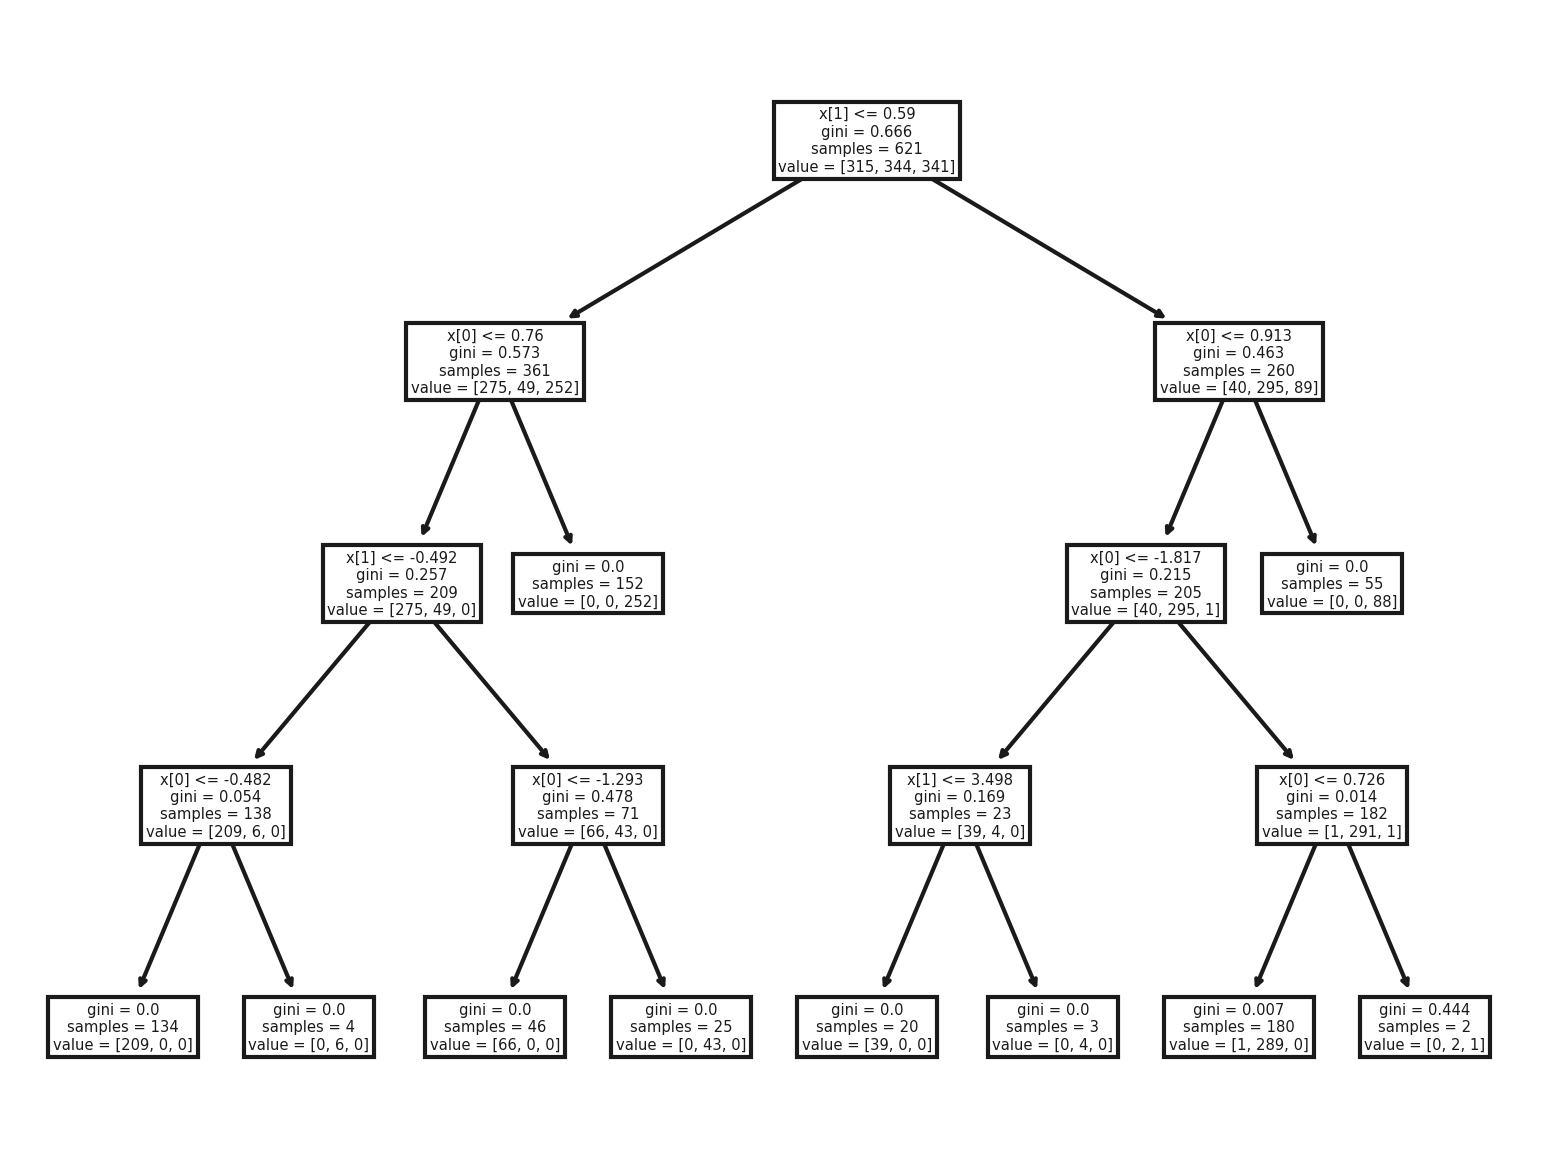

In [ ]:
plt.figure(dpi=300)
with plt.style.context('classic'):
  tree.plot_tree(rfc.estimators_[20]);

## Boosted Decision Trees (XGBoost)

Another approach to the ensemble tree modeling is Boosted Decision Trees. In a boosting framework, the trees are created sequentially. This way each next tree reduces error of the ensemble, by adding corrections to previous predictions.

Corrections to the predictions of boosted decision trees are sequentially added, in contrast with random forest predictions:

$$ Boost(x) = Tree_0(x)+\lambda \sum_{i=1}^{N_\text{trees}} Tree_i(x)$$

Notes:

- The trees used at each step are very shallow trees (with high biased). Boosting is a way to combine `weak` classifiers (high bias, low variance) and decrease bias and increase variance gradually, in a controlled way.

- $\lambda$ is a parameters, called shrinkage or learning rate, that describes how fast we are changing the predictions at each step. A smaller learning rate is useful to control overfitting.

- Predictions and classifications are treated often on the same footing, by making the ensemble output logits.



One of the most popular implementations of boosting is XGBoost:

https://arxiv.org/abs/1603.02754

https://xgboost.readthedocs.io/en/stable/python/python_api.html

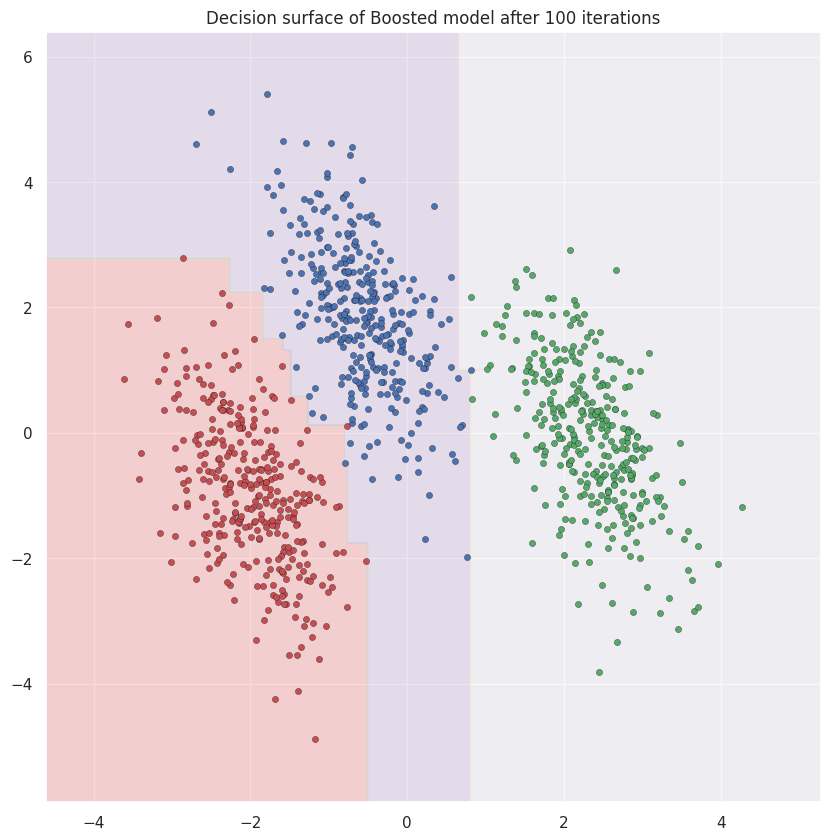

In [ ]:
from xgboost import XGBClassifier

# make 3-class dataset for classification
centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=40)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

params = {
    'num_class': 3,               # Number of classes in the target variable
    'max_depth': 3,               # Maximum depth of trees
    'learning_rate': 0.1,         # Learning rate
    'n_estimators': 100
}
model = XGBClassifier(**params)
model.fit(X, y, verbose=True)

# print the training scores
#print("training score : %.3f (n_est=%d)" % (dtc.score(X, y), n_est))
x_0 = X[:, 0]
x_1 = X[:, 1]
x_min = x_0.min() - 1
x_max = x_0.max() + 1
y_min = x_1.min() - 1
y_max = x_1.max() + 1
plt.figure(figsize=(10,10))
plot_prediction_2d(x_min, x_max, y_min, y_max, classifier = model)

plt.title(f'Decision surface of Boosted model after 100 iterations')
plt.axis('tight')

# Plot also the training points
colors = 'rbg'
for i, color in enumerate(colors):
    idx = np.where(y == i)
    plt.scatter(x_0[idx], x_1[idx], c=color,
                edgecolor='black', s=20, linewidth=0.2)

# Plot the three one-against-all classifiers
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()


plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

x, y = house_prices_dataset()

# Split your data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

evals_result = {}
# Create an XGBoost regression model
model = XGBRegressor(eval_metric='rmse' ,
                     max_depth = 5,
                     early_stopping_rounds = 10,
                     learning_rate = 0.3,
                     n_estimators = 1000 )

# Train the XGBoost regression model
model.fit(x_train, y_train,
          eval_set=[(x_train, y_train),(x_test, y_test)],
          verbose=True)

y_p_train = model.predict(x_train)
y_p_test = model.predict(x_test)

In [ ]:
plt.plot(model.evals_result_['validation_0']['rmse'], label='train')
plt.plot(model.evals_result_['validation_1']['rmse'], label='test')
plt.legend()
plt.xlabel('Number of Estimators')
plt.ylabel('RMSE')
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# mse
print('train mse =', np.std(y_train - y_p_train))
print('test mse =', np.std(y_test - y_p_test))

residuals=y_train - y_p_train
print('train mse =', np.sqrt( np.mean(residuals**2)) )
residuals=y_test - y_p_test
print('train mse =', np.sqrt( np.mean(residuals**2)) )

# mse
print('train mae =', np.mean(np.abs(y_train - y_p_train)))
print('test mae =', np.mean(np.abs(y_test - y_p_test)))
# R2
print('train R2 =', r2_score(y_train, y_p_train))
print('test R2 =', r2_score(y_test, y_p_test))


# 4. plot y vs predicted y for test and train parts
plt.figure(figsize=(10,10))
plt.plot(y_train, y_p_train, 'b.', label='train')
plt.plot(y_test, y_p_test, 'r.', label='test')

plt.plot(y_train, y_train,'-')

plt.plot([0], [0], 'w.')  # dummy to have origin
plt.xlabel('true')
plt.ylabel('predicted')
plt.gca().set_aspect('equal')
plt.legend()
plt.plot()

## EXERCISE: Random forest for FMNIST

Classify fashion MNIST images with Random Forest classifier. This is similar to Ex 2 (Logistic Regression for FMNIST) but you have to play with a different classifier.

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
# Repeat the steps of Ex. 2, but in step 3 when fitting the model, you can play with r.f. parameters.

# TIP:  You can use verbose = 2 to see the training progress (in case it is too slow) and n_jobs=-1 to use all available corse: ensemble.RandomForestClassifier(..., verbose=2, n_jobs=-1)

Once you are done, call clf.get_params() and update the google doc here with your findindgs!

https://docs.google.com/document/d/1f5sDOS_cq1_ZaUkwlSnog5I8jpYiK_QAF1hk3vcBFL8/edit?usp=sharing

## Interpretable Machine Learning: Feature Importance

Understanding how a model makes decisions is a key aspect of **Interpretable Machine Learning**. This is crucial for:

* debugging
* model development
* building trust in predictions
* generalizability

Many methods produce a feature importance plot. The simplest approach is **Permutation Feature Importance** ([scikit-learn documentation](https://scikit-learn.org/stable/modules/permutation_importance.html)):

---

### Permutation Feature Importance: Methodology

1. **Train Model**
    - Fit the model on training data and compute the `baseline_score`.
2. **For each feature `f`:**
    - Shuffle `f` in the validation data.
    - Compute the `shuffled_score` using the trained model.
    - Calculate `importances[f] = baseline_score - shuffled_score`.
3. **(Optional) Normalization**
    - Normalize the `importances` vector so all values are positive and sum to one.

---

For **Random Forest** models, another type of feature importance is available as a model attribute. This method is much faster to plot than permutation feature importance.

### Feature Importance in Practice

Below is a code snippet demonstrating how to compute and compare permutation feature importance and Random Forest feature importance for Exercise 3 (see Solutions for full code):

```python
# Permutation Feature Importance
from sklearn.inspection import permutation_importance
p_importances = permutation_importance(
    clf, test_features, test_labels, n_repeats=10, n_jobs=-1
)

# Random Forest Feature Importance
rf_importances = clf.feature_importances_
```

- `p_importances`: Measures the decrease in model score when a feature is randomly shuffled, indicating its impact on predictions.
- `rf_importances`: Directly provided by the Random Forest model, reflecting the average decrease in impurity across all trees for each feature.

<img src="https://github.com/neworldemancer/DSF5/raw/master/figures/FMNIST_feature_importance.png" width="80%"/>
<img src="https://github.com/neworldemancer/DSF5/raw/master/figures/FMNIST_feature_importance_2.png" width="80%"/>

LIMITATIONS:

1.  The samples generated may be out-of-distribution, therefore uninteresting or belonging to a region where the model returns random values
2.  In the presence of correlated features a model can rely on one or the other feature for prediction. This may lead to misleading interpetations.

PARTIAL SOLUTION: perform a study of the correlation between the variables to interpret the validation plot.





FURTHER READINGS (advanced):

Feature importance provide an important which is independent of the samle. SHAP (and LIME) provide a sample dependent feature importance, https://shap.readthedocs.io/en/latest/overviews.html . Other readings:

1. "Why Should I Trust You?": Explaining the Predictions of Any Classifier, https://arxiv.org/abs/1602.04938
2. "Explaining individual predictions when features are dependent: More accurate approximations to Shapley values", https://arxiv.org/abs/1903.10464

## EXERCISE: Random forest for AMES with Feature Imporance


In [ ]:
X, y, (df_x, df_y) = house_prices_dataset(return_df_xy=True)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Predict the house prices using either a RandomForest model or boosted tree (choose one). Suggestion:

```python
model = ensemble.RandomForestRegressor(max_depth=... n_estimators= ...)
```

Use permutation importance for the feature importance.

In [ ]:
# 1. Review the examples showcasing the usage of the random forest model or xgboost.

# 2. Fit the model

# 3. Inspect training and test accuracy

# 4. Try to improve performance by adjusting hyperparameters.
# How does it compare to linear model? Can you make a plot of y_pred vs y_exact as you did for a linear model and compare visually ?

# 5. Study the feature importance


# Helper code for plotting the permutation feature importances in this dataset:
def plot_importances(feature_names, permutation_importances):
        """
        Plots horizontal bar chart of permutation feature importances.

        Parameters
        ----------
        feature_names : list or array-like
                Names of the features corresponding to the importances.
        permutation_importances :
                Output from sklearn.inspection.permutation_importance, containing
                importances_mean and importances_std for each feature.

        Returns
        -------
        None
                Displays the plot.
        """
        plt.figure(figsize=(8, 10))
        plt.barh(feature_names,
                        permutation_importances.importances_mean,
                        yerr=permutation_importances.importances_std, )
        plt.ylabel('feature')
        plt.xlabel('importance')
        plt.xlim(0, 1)
        return